In [13]:
import math
from iminuit import Minuit
import matplotlib.pyplot as plt

In [14]:
# fixed efficiencies (from simulation)
fixed_e = {"eQx": 0.000157, "eQc": 0.001112}
#fixed correlations (from simulation)
fixed_rho = {
        # "b" correlations 
        ("b", "Q", "Q"): -0.024388875695073087,
        ("b", "Q", "S"): -0.014681408973825416,
        ("b", "Q", "L"): -0.01478104029968752,
        ("b", "Q", "X"): 0.025460339350633854,
        ("b", "Q", "C"): -0.005259540244790473,
        ("b", "S", "S"): -0.03251168991502096,
        ("b", "S", "L"): -0.00866788403752039,
        ("b", "S", "C"): -0.05224735588293217,
        ("b", "S", "X"): 0.008141486420410349,
        ("b", "L", "L"): -0.026745888870009615,
        ("b", "L", "C"): 0.0006933836185840647,
        ("b", "L", "X"): -0.01720332891996601,
        ("b", "X", "X"): -0.28228189903976975,
        ("b", "X", "C"): -0.05534734736922631,
        ("b", "C", "C"): 0.12249521565709798,
        # "c" correlations
        ("c", "Q", "Q"): 0.00,
        ("c", "Q", "S"): 0.02200888192267514,
        ("c", "Q", "L"): 0.32383861595229413,
        ("c", "Q", "X"): -0.3358432846494449,
        ("c", "Q", "C"): -0.45597690809339875,
        ("c", "S", "S"): 0.313513688016529,
        ("c", "S", "L"): -0.1254869804021751,
        ("c", "S", "C"): -0.2428853456079546,
        ("c", "S", "X"): -0.32369223565269056,
        ("c", "L", "L"): -0.05286185806617372,
        ("c", "L", "C"): -0.25411230406197116,
        ("c", "L", "X"): -0.23723294295036723,
        ("c", "C", "C"): -0.1873009162087722,
        ("c", "X", "C"): -0.1679674097428946,
        ("c", "X", "X"): -0.20079015675450818,
        # "x" correlations
        ("x", "Q", "Q"): 0.00,
        ("x", "Q", "S"): 0.00,
        ("x", "Q", "L"): 0.00,
        ("x", "Q", "X"): -0.23000067021018822,
        ("x", "Q", "C"): 0.24537710021262704,
        ("x", "S", "S"): 0.00,
        ("x", "S", "L"): 0.9531788662829419,
        ("x", "S", "C"): 0.0729587558995426,
        ("x", "S", "X"): -0.2542038329352746,
        ("x", "L", "L"): 0.42939899111804647,
        ("x", "L", "C"): -0.137618253953539,
        ("x", "L", "X"): -0.21427849550468714,
        ("x", "C", "C"): -0.12831737388122078,
        ("x", "X", "C"): -0.1504458080376524,
        ("x", "X", "X"): -0.12470610714608843,
                }
# data counted events number
eventsNumber = {
        "N_tot": 945506,
        "single": {
            "Q": 22239,
            "S": 14160,
            "L": 33277,
            "X": 268127,
            "C": 56936,
        },
        "double": {
            ("Q", "Q"): 29148,
            ("S", "S"):8622,
            ("L", "L"): 9833,
            ("X", "X"): 196813,
            ("C", "C"): 16308,
            ("Q", "S"): 31665,
            ("Q", "L"):31308,
            ("Q", "X"): 5640,
            ("Q", "C"): 7102,
            ("S", "L"): 16919,
            ("S", "X"): 4883,
            ("S", "C"): 4932,
            ("L", "X"): 22723,
            ("L", "C"): 11640,
            ("X", "C"): 37854,
        }
    }

MC_eventsNumber = {
        "N_tot": 930302.541871,
        "single": {
            "Q": 21801.194,
            "S": 12613.351,
            "L": 28194.931,
            "X": 261879.585,
            "C": 57496.439,
        },
        "double": {
            ("Q", "Q"): 33734.325,
            ("S", "S"): 8315.601,
            ("L", "L"): 9134.142,
            ("X", "X"): 206210.625,
            ("C", "C"): 18177.155,
            ("Q", "S"): 33908.449,
            ("Q", "L"): 32912.529,
            ("Q", "X"): 5087.000,
            ("Q", "C"): 6445.811,
            ("S", "L"): 16733.723,
            ("S", "X"): 3347.395,
            ("S", "C"): 3947.876,
            ("L", "X"): 14502.668,
            ("L", "C"): 10935.585,
            ("X", "C"): 30154.223,
        }
    }

# prefit events number
prefit_eventsNumber = {
        "N_tot": 945506,
        "single": {
            "Q": 22069.481294,
            "S": 13203.575038,
            "L": 32683.652732,
            "X": 313264.071692,
            "C": 72116.819667,
        },
        "double": {
            ("Q", "Q"): 34056.199411,
            ("S", "S"): 8390.223661,
            ("L", "L"): 9552.676683,
            ("X", "X"): 245793.067872,
            ("C", "C"): 23102.798691,
            ("Q", "S"): 34234.481731,
            ("Q", "L"): 33232.478573,
            ("Q", "X"): 5158.992794,
            ("Q", "C"): 6525.407345,
            ("S", "L"): 16964.937230,
            ("S", "X"): 3574.389751,
            ("S", "C"): 4230.432015,
            ("L", "X"): 17130.061632,
            ("L", "C"): 13107.082184,
            ("X", "C"): 37136.122211,
        }
    }
# Rc
Rc = 0.172

class RbFit:
    def __init__(self, events, fixed_e, fixed_rho, Rc=0.172):
        self.events = events
        self.fixed_e = fixed_e
        self.fixed_rho = fixed_rho
        self.Rc = Rc
        self.tags = ["Q", "S", "L", "X", "C"]
        self.tag_order = {t: i for i, t in enumerate(self.tags)}

    def predict(self, Rb, eQb, eSx, eSc, eSb,
                eLx, eLc, eLb, eCx, eCc, eCb,
                eXx, eXc, eXb):

        epsilon_b = {"Q": eQb, "S": eSb, "L": eLb, "C": eCb, "X": eXb}
        epsilon_c = {"Q": self.fixed_e["eQc"], "S": eSc, "L": eLc, "C": eCc, "X": eXc}
        epsilon_x = {"Q": self.fixed_e["eQx"], "S": eSx, "L": eLx, "C": eCx, "X": eXx}

        N_tot = self.events["N_tot"]
        
        # compute fsI
        fs = {}
        for I in self.tags:
            fs[I] = (Rb*epsilon_b[I]+Rc*epsilon_c[I]+(1-Rb-Rc)*epsilon_x[I])

        # compute fdIJ
        fd = {}
        pred_double = {}
        for i, I in enumerate(self.tags):
            for J in self.tags[i:]:
                coeff = 1.0 if J == I else 2.0
                fd[(I, J)] = (
                    Rb*epsilon_b[I]*epsilon_b[J]*(1+self.fixed_rho[("b", I, J)])+
                    Rc*epsilon_c[I]*epsilon_c[J]*(1+self.fixed_rho[("c", I, J)])+
                    (1-Rb-Rc)*epsilon_x[I]*epsilon_x[J]*(1+self.fixed_rho[("x", I, J)])
                )
                pred_double[(I, J)] = N_tot * fd[(I, J)]*coeff
                #N_d + [pred_double[(I, J)]]
                #print(f"predict double {I}{J}", pred_double[(I, J)])

        # compute singly tagged
        '''
        pred_single = {}
        for I in self.tags:
            sum_fd_singly = 0.0
            for J in self.tags:
                key = (I, J) if self.tag_order[I] <= self.tag_order[J] else (J, I)
                #print(f"{I}{J}")
                coeff = 1.0 if J == I else 2.0
                sum_fd_singly += fd[key]*coeff
            pred_single[I] = N_tot * (2.0 * fs[I] - sum_fd_singly)
            #print(f"predict single {I}", pred_single[I])
        '''
        pred_single = {}
        for I in self.tags:
            sum_fd_singly = 0.0
            for J in self.tags:
                key = (I, J) if self.tag_order[I] <= self.tag_order[J] else (J, I)
                sum_fd_singly += 2.0 * fd[key]
            pred_single[I] = N_tot * (2.0 * fs[I] - sum_fd_singly)
        return {"single": pred_single, "double": pred_double}
    
    def nll(self, Rb, eQb, eSx, eSc, eSb,
            eLx, eLc, eLb, eCx, eCc, eCb,
            eXx, eXc, eXb):

        pred = self.predict(Rb, eQb, eSx, eSc, eSb,
                            eLx, eLc, eLb, eCx, eCc, eCb,
                            eXx, eXc, eXb)

        total = 0.0

        for I, obs in self.events["single"].items():
            mu = pred["single"][I]
            if mu <= 0:
                return 1e30
            # NEW: Numerically stable Poisson NLL
            if obs > 0:
                total += mu - obs + obs * math.log(obs / mu)
                #total += mu - obs * math.log(mu)
            else:
                total += mu

        for IJ, obs in self.events["double"].items():
            mu = pred["double"][IJ]
            if mu <= 0:
                return 1e30
            # NEW: Numerically stable Poisson NLL
            if obs > 0:
                total += mu - obs + obs * math.log(obs / mu)
                #total += mu - obs * math.log(mu)
            else:
                total += mu

        return total


In [7]:
fit = RbFit(prefit_eventsNumber, fixed_e, fixed_rho, Rc=0.172)
'''
m = Minuit(
    fit.nll,
    Rb=0.2158,
    eQb=0.19, eSb=0.18, eLb=0.04, eCb=0.026, eXb=0.002,
    eSc=0.01, eLc=0.01, eCc=0.2, eXc=0.04,
    eSx=0.002, eLx=0.002, eCx=0.08, eXx=0.1,
)
'''
m = Minuit(
    fit.nll,
    Rb=0.2158,
    eQb=0.413619, eSb=0.205819, eLb=0.199547, eCb=0.038347, eXb=0.029007,
    eSc=0.011247, eLc=0.095508, eCc=0.412001, eXc=0.173065,
    eSx=0.001157, eLx=0.017041, eCx=0.025627, eXx=0.690799,
)
m.errordef = Minuit.LIKELIHOOD
#m.limits["Rb"] = (0.1, 0.3)

#for p in m.parameters:
#    if p != "Rb":
#        m.limits[p] = (0.0, 1)

m.migrad()
m.hesse()
m.minos()


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 2.645e-12                  │             Nfcn = 3702              │
│ EDM = 3.37e-11 (Goal: 0.0001)    │            time = 0.1 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ Rb   │ 215.8e-3  │  0.6e-3   │  -0.6e-3   │   0.6e-3   │         │         │       │
│ 1 │ eQb  │  0.4136   │  0.0011   │  -0.0011   │   0.0011   │         │         │       │
│ 2 │ eSx  │  1.16e-3  │  0.13e-3  │  -0.13e-3  │  0.13e-3   │         │         │       │
│ 3 │ eSc  │  11.2e-3  │  0.7e-3   │  -0.7e-3   │   0.7e-3   │         │         │       │
│ 4 │ eSb  │ 205.8e-3  │  0.7e-3   │  -0.7e-3   │   0.7e-3   │         │         │       │
│ 5 │ eLx  │ 17.04e-3  │  0.23e-3  │  -0.22e-3  │  0.22e-3   │         │         │       │
│ 6 │ eLc  │  0.0955   │  0.0011   │  -0.0011   │   0.0011   │         │         │       │
│ 7 │ eLb  │ 199.5e-3  │  0.7e-3   │  -0.7e-3   │   0.7e-3   │         │         │       │
│ 8 │ eCx  │ 25.63e-3  │  0.32e-3  │  -0.32e-3  │  0.32e-3   │         │         │       │
│ 9 │ eCc  │  0.4120   │  0.0014   │  -0.0014   │   0.0014   │         │         │       │
│ 10│ eCb  │  38.3e-3  │  0.5e-3   │  -0.5e-3   │   0.5e-3   │         │         │       │
│ 11│ eXx  │ 690.8e-3  │  0.7e-3   │  -0.7e-3   │   0.7e-3   │         │         │       │
│ 12│ eXc  │  0.1731   │  0.0016   │  -0.0016   │   0.0016   │         │         │       │
│ 13│ eXb  │  29.0e-3  │  0.4e-3   │  -0.4e-3   │   0.4e-3   │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          Rb           │          eQb          │          eSx          │          eSc          │          eSb          │          eLx          │          eLc          │          eLb          │          eCx          │          eCc          │          eCb          │          eXx          │          eXc          │          eXb          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │  -0.6e-3  │  0.6e-3   │  -0.0011  │  0.0011   │ -0.13e-3  │  0.13e-3  │  -0.7e-3  │  0.7e-3   │  -0.7e-3  │  0.7e-3   │ -0.22e-3  │  0.22e-3  │  -0.0011  │  0.0011   │  -0.7e-3  │  0.7e-3   │ -0.32e-3  │  0.32e-3  │  -0.0014  │  0.0014   │  -0.5e-3  │  0.5e-3   │  -0.7e-3  │  0.7e-3   │  -0.0016  │  0.0016   │  -0.4e-3  │  0.4e-3   │
│  Valid   │   True    │   True    │   True    │   Tru

In [8]:
paper_vals = dict(
    Rb=0.2158,
    eQb=0.413619, eSb=0.205819, eLb=0.199547, eCb=0.038347, eXb=0.029007,
    eSc=0.011247, eLc=0.095508, eCc=0.412001, eXc=0.173065,
    eSx=0.001157, eLx=0.017041, eCx=0.025627, eXx=0.690799,
)

pred = fit.predict(**paper_vals)

print("Singles:")
for k, obs in prefit_eventsNumber["single"].items():
    exp = pred["single"][k]
    print(k, obs, exp, obs-exp)

print("\nDoubles:")
for k, obs in prefit_eventsNumber["double"].items():
    exp = pred["double"][k]
    print(k, obs, exp, obs-exp)

Singles:
Q 22069.481294 22069.4812944487 -4.486973921302706e-07
S 13203.575038 13203.575037643066 3.569348336895928e-07
L 32683.652732 32683.65273207358 -7.358175935223699e-08
X 313264.071692 313264.07169201475 -1.4726538211107254e-08
C 72116.819667 72116.81966699746 2.546585164964199e-09

Doubles:
('Q', 'Q') 34056.199411 34056.19941101477 -1.4770193956792355e-08
('S', 'S') 8390.223661 8390.223660788635 2.1136474970262498e-07
('L', 'L') 9552.676683 9552.676682712028 2.879714884329587e-07
('X', 'X') 245793.067872 245793.06787168907 3.109453245997429e-07
('C', 'C') 23102.798691 23102.79869090356 9.643918019719422e-08
('Q', 'S') 34234.481731 34234.48173145315 -4.5314664021134377e-07
('Q', 'L') 33232.478573 33232.47857275876 2.4124165065586567e-07
('Q', 'X') 5158.992794 5158.992793965359 3.464083420112729e-08
('Q', 'C') 6525.407345 6525.407345259696 -2.5969620764954016e-07
('S', 'L') 16964.93723 16964.93722983685 1.6314879758283496e-07
('S', 'X') 3574.389751 3574.3897505465743 4.5342585508

In [9]:
print("Best-fit Rb =", m.values["Rb"])
for p in m.parameters:
    if p != "Rb":
        print(f"corr(Rb, {p}) = {m.covariance.correlation()['Rb', p]: .3f}")

Best-fit Rb = 0.2158
corr(Rb, eQb) = -0.495
corr(Rb, eSx) = -0.111
corr(Rb, eSc) = -0.381
corr(Rb, eSb) = -0.035
corr(Rb, eLx) = -0.104
corr(Rb, eLc) = -0.283
corr(Rb, eLb) =  0.084
corr(Rb, eCx) = -0.300
corr(Rb, eCc) =  0.023
corr(Rb, eCb) =  0.303
corr(Rb, eXx) =  0.305
corr(Rb, eXc) =  0.383
corr(Rb, eXb) =  0.219


In [10]:
#m.migrad()
#m.hesse()
#m.minos

print("=== Fit status ===")
print(m.fmin)
print()

print("=== Best-fit values ===")
for p in m.parameters:
    print(f"{p:>5s} = {m.values[p]:.6g} +/- {m.errors[p]:.6g}")
print()

print("valid minimum:", m.valid)
print("fval (NLL) =", m.fval)

# optional Pearson-style diagnostic
pred_post = fit.predict(
    m.values["Rb"],
    m.values["eQb"], m.values["eSx"], m.values["eSc"], m.values["eSb"],
    m.values["eLx"], m.values["eLc"], m.values["eLb"], m.values["eCx"],
    m.values["eCc"], m.values["eCb"], m.values["eXx"], m.values["eXc"],
    m.values["eXb"]
)

chi2 = 0.0
nobs = 0

for I, obs in prefit_eventsNumber["single"].items():
    exp = pred_post["single"][I]
    chi2 += (obs - exp) ** 2 / exp
    nobs += 1

for IJ, obs in prefit_eventsNumber["double"].items():
    exp = pred_post["double"][IJ]
    chi2 += (obs - exp) ** 2 / exp
    nobs += 1

ndof = nobs - m.nfit
print("Pearson chi2 =", chi2)
print("ndof =", ndof)
print("chi2/ndof =", chi2 / ndof if ndof > 0 else float("nan"))
print()

if m.valid:
    m.minos()
    print("=== Minos errors ===")
    for p in m.parameters:
        if p in m.merrors:
            print(f"{p:>4s} : {m.merrors[p].lower:.6g} / +{m.merrors[p].upper:.6g}")
else:
    print("Minimum is not valid, so minos() was skipped.")

=== Fit status ===
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 2.645e-12                  │             Nfcn = 3702              │
│ EDM = 3.37e-11 (Goal: 0.0001)    │            time = 0.1 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘

=== Best-fit values ===
   Rb = 0.2158 +/- 0.000592058
  eQb = 0.413

In [11]:
import pandas as pd
import numpy as np

# postfit prediction from best-fit parameters
pred_postfit = fit.predict(
    m.values["Rb"],
    m.values["eQb"], m.values["eSx"], m.values["eSc"], m.values["eSb"],
    m.values["eLx"], m.values["eLc"], m.values["eLb"], m.values["eCx"],
    m.values["eCc"], m.values["eCb"], m.values["eXx"], m.values["eXc"],
    m.values["eXb"]
)

rows = []

for tag, obs in prefit_eventsNumber["single"].items():
    post = pred_postfit["single"][tag]
    pre = pred["single"][tag]
    rows.append({
        "category": "single",
        "tag": tag,
        "sim": obs,
        "prefit": pre,
        "postfit": post,
        #"MC-postfit": obs - post,
        "postfit-prefit": post-pre,
      #  "data/postfit": obs / post if post != 0 else np.nan
    })

for tag, obs in prefit_eventsNumber["double"].items():
    post = pred_postfit["double"][tag]
    pre = pred["double"][tag]
    rows.append({
        "category": "double",
        "tag": f"{tag[0]},{tag[1]}",
        "sim": obs,
        "postfit": post,
        "prefit": pre,
        #"MC-postfit": obs - post,
        "postfit-prefit": post-pre,
       # "data/postfit": obs / post if post != 0 else np.nan
    })

df_postfit = pd.DataFrame(rows)
display(df_postfit.style.format({
    "postfit": "{:.3f}",
    #"MC-postfit": "{:+.3f}",
    "data/postfit": "{:.4f}",
}))

,category,tag,sim,prefit,postfit,postfit-prefit
0,single,Q,22069.481294,22069.481294,22069.481,0.000000
1,single,S,13203.575038,13203.575038,13203.575,0.000000
2,single,L,32683.652732,32683.652732,32683.653,0.000000
3,single,X,313264.071692,313264.071692,313264.072,0.000000
4,single,C,72116.819667,72116.819667,72116.820,0.000000
5,double,"Q,Q",34056.199411,34056.199411,34056.199,0.000000
6,double,"S,S",8390.223661,8390.223661,8390.224,0.000000
7,double,"L,L",9552.676683,9552.676683,9552.677,0.000000
8,double,"X,X",245793.067872,245793.067872,245793.068,0.000000
9,double,"C,C",23102.798691,23102.798691,23102.799,0.000000


/var/folders/gj/vw9b6x7d1hsbwfrbr4rxd1d00000gn/T/ipykernel_89391/2303711051.py:91: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


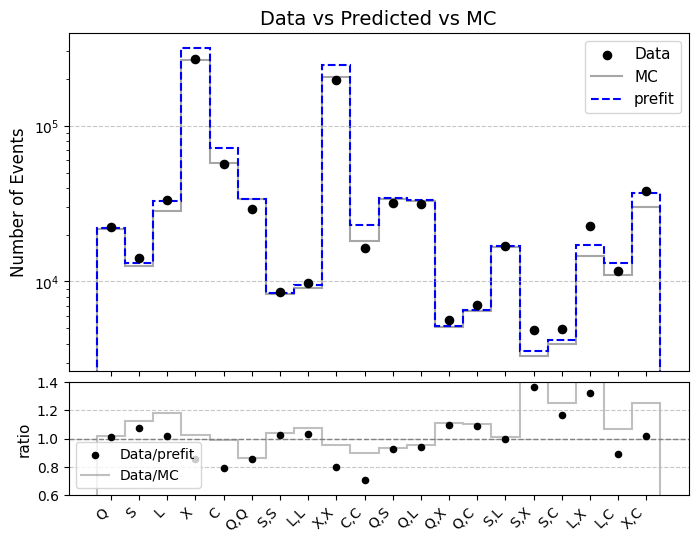

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Postfit prediction
# -------------------------
predictions = fit.predict(
    m.values["Rb"],
    m.values["eQb"], m.values["eSx"], m.values["eSc"], m.values["eSb"],
    m.values["eLx"], m.values["eLc"], m.values["eLb"], m.values["eCx"],
    m.values["eCc"], m.values["eCb"], m.values["eXx"], m.values["eXc"],
    m.values["eXb"]
)

# 1. Prepare Data for Single Tags
single_tags = list(eventsNumber["single"].keys())
#single_obs = np.array([MC_eventsNumber["single"][t] for t in single_tags], dtype=float)
#single_pred = np.array([predictions["single"][t] for t in single_tags], dtype=float)
single_mc = np.array([MC_eventsNumber["single"][t] for t in single_tags], dtype=float)
single_prefitpred = np.array([pred["single"][t] for t in single_tags], dtype=float)
single_data = np.array([eventsNumber["single"][t] for t in single_tags], dtype=float)

# 2. Prepare Data for Double Tags
double_tags = list(eventsNumber["double"].keys())
double_tags_str = [f"{t[0]},{t[1]}" for t in double_tags]
#double_obs = np.array([MC_eventsNumber["double"][t] for t in double_tags], dtype=float)
#double_pred = np.array([predictions["double"][t] for t in double_tags], dtype=float)
double_mc = np.array([MC_eventsNumber["double"][t] for t in double_tags], dtype=float)
double_prefitpred = np.array([pred["double"][t] for t in double_tags], dtype=float)
double_data = np.array([eventsNumber["double"][t] for t in double_tags], dtype=float)

# 3. Combine single + double into one axis
all_tags = single_tags + double_tags_str
#all_obs = np.concatenate([single_obs, double_obs]) # MC
#all_pred = np.concatenate([single_pred, double_pred]) # postfit 
all_prefitpred = np.concatenate([single_prefitpred, double_prefitpred]) # prefit 
all_mc = np.concatenate([single_mc, double_mc]) # mc
all_data = np.concatenate([single_data, double_data]) # data

all_ratio = np.divide(
    all_data, all_prefitpred,
    out=np.full_like(all_data, np.nan),
    where=all_prefitpred != 0
)

all_ratio_mc = np.divide(
    all_data, all_mc,
    out=np.full_like(all_data, np.nan),
    where=all_prefitpred != 0
)

# 4. Build bin edges for categorical histogram
n = len(all_tags)
edges = np.arange(n + 1)
centers = np.arange(n) + 0.5

# 5. Plot
fig = plt.figure(figsize=(8, 6))
gs = fig.add_gridspec(2, 1, height_ratios=[3, 1], hspace=0.05)

ax = fig.add_subplot(gs[0])
axr = fig.add_subplot(gs[1], sharex=ax)

# Main plot: data points + dashed step histogram
#ax.scatter(centers, all_data, label="Data", s=35, zorder=3, color = "red")
ax.scatter(centers, all_data, label="Data", s=35, zorder=3, color = "black")
ax.stairs(all_mc, edges, label="MC", linewidth=1.5, linestyle="-", color = "grey",alpha=0.7)
ax.stairs(all_prefitpred, edges, label="prefit", linewidth=1.5, linestyle="--", color = "blue")
#ax.stairs(all_pred, edges, label="Postfit", linewidth=1.5, linestyle="-", color = "mediumorchid")


ax.set_ylabel("Number of Events", fontsize=12)
ax.set_title("Data vs Predicted vs MC", fontsize=14)
ax.legend(fontsize=11)
ax.grid(axis="y", linestyle="--", alpha=0.7)
ax.tick_params(axis="x", labelbottom=False)
ax.set_yscale('log')

# Ratio panel: points
axr.axhline(1.0, color="grey", linestyle="--", linewidth=1)
axr.scatter(centers, all_ratio, s=20, color="black", zorder=3,label="Data/prefit")
axr.stairs(all_ratio_mc, linewidth=1.5, linestyle="-", color="grey",label="Data/MC",alpha=0.5)
#axr.stairs(all_ratio_prefit, edges, label="prefit/postfit", linewidth=2, linestyle="--")
axr.set_ylabel("ratio", fontsize=11)
axr.set_xticks(centers)
axr.set_xticklabels(all_tags, rotation=45, ha="right", fontsize=10)
axr.grid(axis="y", linestyle="--", alpha=0.7)
axr.legend()
axr.set_ylim(0.6, 1.4)

plt.tight_layout()
plt.show()